# PART 7

Haikal Ali_1103223071_TK46GAB

# SLC 7 - Support Vector Machines dan Kernel Methods

Notebook ini dibuat berdasarkan materi SLC 7. Bagian teori ditulis sebagai markdown, sedangkan bagian yang memang memiliki kode pada materi dibuat sebagai code cell.

## Technical requirements

Materi menyarankan penggunaan environment Python terpisah agar pekerjaan aman dari instalasi atau library Python lain.

Kebutuhan teknis:

- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub yang sudah di-clone dan environment Python yang dibuat dari file `requirements.txt`

## Introduction to SVMs

Support Vector Machines atau SVM adalah model machine learning yang dapat digunakan untuk tugas klasifikasi dan regresi. SVM efektif ketika jumlah fitur besar dibandingkan jumlah sampel, ketika data berdimensi tinggi, atau ketika kelas tidak mudah dipisahkan secara langsung dari fitur awalnya.

Ide utama SVM adalah mencari hyperplane yang memaksimalkan margin antar kelas. Margin adalah jarak antara hyperplane dan titik data terdekat dari masing-masing kelas. Titik terdekat tersebut disebut support vectors. Dengan memaksimalkan margin, SVM berusaha mengurangi kesalahan generalisasi saat memprediksi data baru.

Dalam konteks SVM, hyperplane berfungsi sebagai decision boundary yang membagi ruang fitur menjadi wilayah kelas yang berbeda.

### Persiapan data untuk SVM

Bagian ini menggunakan dataset Iris dari scikit-learn, lalu membaginya menjadi data training dan data testing.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### Implementasi SVM untuk klasifikasi

Model SVM classifier dibuat menggunakan kernel linear, kemudian dilatih dengan data training dan dievaluasi menggunakan accuracy serta classification report.

In [2]:
svm_classifier = SVC(kernel='linear')

svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

styled_df = (report_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"Accuracy: {accuracy:.2f}")
styled_df

Accuracy: 0.93


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.909,0.833,0.870,12
2,0.875,0.933,0.903,15
accuracy,0.933,0.933,0.933,1
macro avg,0.928,0.922,0.924,45
weighted avg,0.934,0.933,0.933,45


Model SVM dengan kernel linear dapat menghasilkan performa klasifikasi yang cukup baik menggunakan parameter default.

### Implementasi SVM untuk regresi

SVM juga dapat digunakan untuk regresi dengan `SVR`. Pada contoh ini digunakan kernel RBF dan metrik Mean Squared Error.

In [3]:
svm_regressor = SVR(kernel='rbf')

svm_regressor.fit(X_train[:, :2], y_train)

y_pred_reg = svm_regressor.predict(X_test[:, :2])

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_reg)
print(f"MSE: {mse:.2f}")

MSE: 0.20


Untuk metrik regresi seperti MSE, MAE, dan MAPE, nilai yang lebih kecil menunjukkan performa yang lebih baik. Namun, batas nilai yang dapat diterima biasanya bergantung pada kebutuhan bisnis atau konteks masalah.

### Cara kerja SVM

SVM bekerja dengan mencari hyperplane yang memaksimalkan margin antar kelas. Jika data tidak dapat dipisahkan secara linear, SVM dapat menggunakan kernel function untuk memetakan data ke ruang berdimensi lebih tinggi agar lebih mudah dipisahkan.

Beberapa konsep penting:

- Kernel functions: kernel umum meliputi linear, polynomial, dan radial basis function (RBF).
- Soft margin: SVM dapat mentoleransi beberapa kesalahan klasifikasi melalui slack variables agar lebih tahan terhadap outlier.

### Visualisasi decision boundary SVM

Visualisasi decision boundary membantu melihat bagaimana SVM membagi ruang fitur. Pada contoh ini, visualisasi hanya memakai dua fitur pertama.

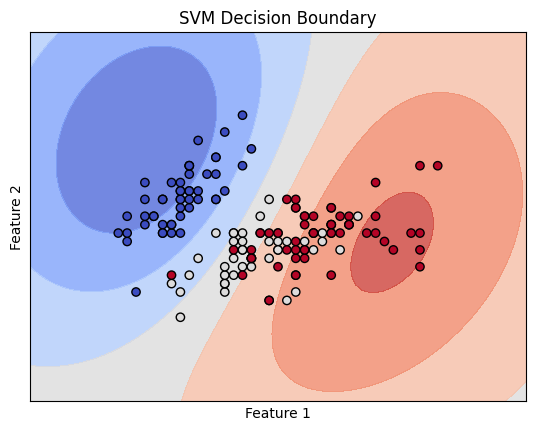

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
  np.arange(x_min, x_max, 0.01),
  np.arange(y_min, y_max, 0.01)
)

grid_points = np.c_[
  xx.ravel(), yy.ravel(),
  np.zeros((xx.ravel().shape[0], 2))
]

fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
  svm_regressor,
  grid_points[:, :2],
  response_method="predict",
  plot_method="contourf",
  cmap=plt.cm.coolwarm,
  alpha=0.8,
  ax=ax
)

ax.scatter(
  X[:, 0], X[:, 1], c=y, edgecolors='k',
  marker='o', cmap=plt.cm.coolwarm
)

ax.set_title("SVM Decision Boundary")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
ax.set_xticks(())
ax.set_yticks(())
plt.show()

Plot kontur tersebut memperlihatkan batas klasifikasi non-linear yang dapat diperkirakan oleh SVM menggunakan kernel trick. Karena batas tersebut sebenarnya diestimasi pada ruang berdimensi lebih tinggi, visualisasi dua dimensi hanya merupakan representasi yang disederhanakan.

### Hands-on exercises

Alur latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Load dataset Iris menggunakan `load_iris()` dari `sklearn.datasets`.
3. Bersihkan dataset dengan menangani missing values dan encoding categorical variables jika diperlukan.
4. Load `SVC` dari `sklearn.svm` untuk tugas klasifikasi.
5. Fit model menggunakan data training.
6. Gunakan `predict` pada data testing.
7. Hitung metrik seperti accuracy score dan classification report.
8. Coba kernel berbeda seperti linear dan RBF untuk melihat pengaruhnya terhadap performa model.

## Kernel functions and their applications

Kernel function adalah elemen penting yang membuat SVM mampu menangani data non-linear. Kernel bekerja dengan memetakan data awal ke ruang berdimensi lebih tinggi sehingga SVM dapat menemukan decision boundary linear pada ruang baru tersebut, yang jika dilihat pada ruang asal dapat menjadi batas non-linear.

Bagian ini membahas kernel linear, polynomial, dan RBF.

### Persiapan data untuk kernel SVM

Dataset yang digunakan kembali adalah Iris.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### SVM dengan polynomial kernel

Polynomial kernel memungkinkan SVM membuat decision boundary yang lebih kompleks dibandingkan kernel linear.

In [6]:
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

accuracy_poly = accuracy_score(y_test, y_pred_poly)
report_poly = classification_report(
  y_test, y_pred_poly, output_dict=True
)
report_df_poly = pd.DataFrame(report_poly).transpose()

styled_df_poly = (report_df_poly
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"Polynomial Kernel Accuracy: {accuracy_poly:.2f}")
styled_df_poly

Polynomial Kernel Accuracy: 0.96


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,1.000,0.833,0.909,12
2,0.882,1.000,0.938,15
accuracy,0.956,0.956,0.956,1
macro avg,0.961,0.944,0.949,45
weighted avg,0.961,0.956,0.955,45


Polynomial kernel dapat memberikan performa lebih baik dibandingkan pendekatan linear apabila struktur data lebih cocok direpresentasikan dengan kombinasi fitur polinomial.

### SVM dengan RBF kernel

RBF kernel memetakan data menggunakan fungsi Gaussian dan umum digunakan untuk hubungan fitur yang kompleks.

In [7]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
report_rbf = classification_report(
  y_test, y_pred_rbf, output_dict=True
)
report_df_rbf = pd.DataFrame(report_rbf).transpose()

styled_df_rbf = (report_df_rbf
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"RBF Kernel Accuracy: {accuracy_rbf:.2f}")
styled_df_rbf

RBF Kernel Accuracy: 0.91


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.786,0.917,0.846,12
2,0.923,0.800,0.857,15
accuracy,0.911,0.911,0.911,1
macro avg,0.903,0.906,0.901,45
weighted avg,0.917,0.911,0.911,45


Pada contoh materi, RBF kernel menghasilkan performa lebih rendah dibandingkan polynomial kernel ketika semua parameter masih default. Hyperparameter optimization dapat digunakan untuk mencoba meningkatkan performanya.

### Cara kerja kernel function

Kernel function memungkinkan SVM bekerja pada ruang berdimensi tinggi tanpa menghitung koordinat data secara eksplisit pada ruang tersebut. Proses ini disebut kernel trick.

Ringkasan kernel:

- Linear kernel: digunakan ketika data dapat dipisahkan secara linear.
- Polynomial kernel: digunakan ketika hubungan antar fitur memiliki pola polinomial.
- RBF kernel: digunakan untuk menangani hubungan fitur yang kompleks.

### Visualisasi pengaruh kernel

Bagian ini memvisualisasikan decision boundary dari kernel linear, polynomial, dan RBF menggunakan dua fitur pertama.

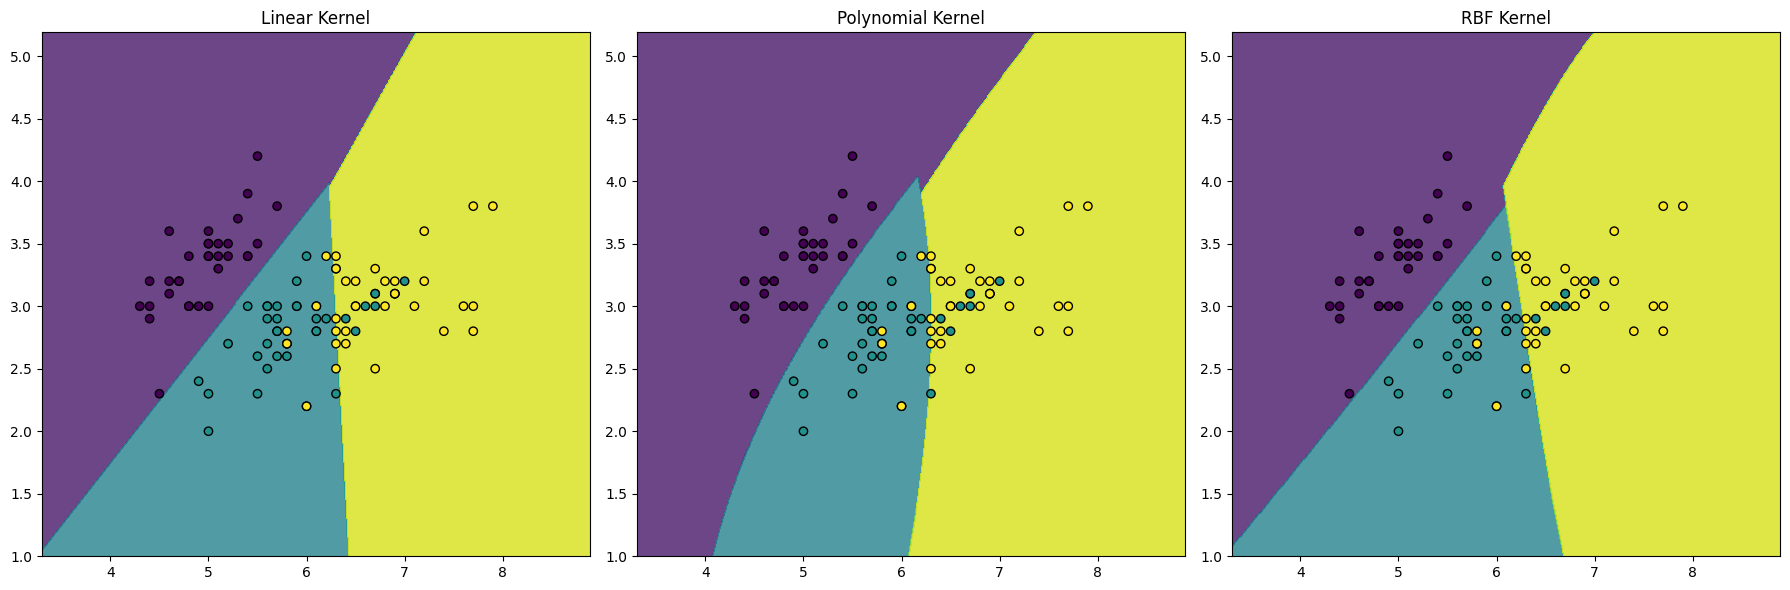

In [8]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(
  np.arange(x_min, x_max, 0.01),
  np.arange(y_min, y_max, 0.01)
)

X_train_2d = X_train[:, :2]

svm_linear_2d = SVC(kernel='linear').fit(X_train_2d, y_train)
svm_poly_2d = SVC(kernel='poly').fit(X_train_2d, y_train)
svm_rbf_2d = SVC(kernel='rbf').fit(X_train_2d, y_train)

Z_linear = svm_linear_2d.predict(
  np.c_[xx.ravel(), yy.ravel()]
)
Z_poly = svm_poly_2d.predict(
  np.c_[xx.ravel(), yy.ravel()]
)
Z_rbf = svm_rbf_2d.predict(
  np.c_[xx.ravel(), yy.ravel()]
)

Z_linear = Z_linear.reshape(xx.shape)
Z_poly = Z_poly.reshape(xx.shape)
Z_rbf = Z_rbf.reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].contourf(xx, yy, Z_linear, alpha=0.8)
axes[0].scatter(
  X_train_2d[:, 0], X_train_2d[:, 1],
  c=y_train, edgecolors='k', marker='o'
)
axes[0].set_title("Linear Kernel")

axes[1].contourf(xx, yy, Z_poly, alpha=0.8)
axes[1].scatter(
  X_train_2d[:, 0], X_train_2d[:, 1],
  c=y_train, edgecolors='k', marker='o'
)
axes[1].set_title("Polynomial Kernel")

axes[2].contourf(xx, yy, Z_rbf, alpha=0.8)
axes[2].scatter(
  X_train_2d[:, 0], X_train_2d[:, 1],
  c=y_train, edgecolors='k', marker='o'
)
axes[2].set_title("RBF Kernel")

plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan bahwa kernel linear menghasilkan batas linear, sedangkan kernel polynomial dan RBF menghasilkan batas non-linear yang lebih kompleks.

### Hands-on exercises

Alur latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Load dataset Iris menggunakan `load_iris()` dari `sklearn.datasets`.
3. Bersihkan dataset dengan menangani missing values dan encoding categorical variables jika diperlukan.
4. Load `SVC` dari `sklearn.svm`.
5. Implementasikan SVM dengan kernel linear, polynomial, dan RBF.
6. Evaluasi performa model menggunakan accuracy score dan classification report.
7. Visualisasikan decision boundary untuk setiap kernel.
8. Coba parameter kernel berbeda seperti `degree` untuk polynomial dan `gamma` untuk RBF.

## Tuning SVM parameters

Hyperparameter tuning adalah langkah penting untuk meningkatkan performa SVM. Dengan menyesuaikan hyperparameter, model dapat menjadi lebih akurat dan robust.

Pada bagian ini digunakan grid search dan cross-validation.

### Persiapan data untuk tuning

Dataset yang digunakan adalah Iris.

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### Grid search untuk SVM

Grid search mengevaluasi seluruh kombinasi hyperparameter pada parameter grid yang diberikan.

In [10]:
param_grid = {
  'C': [0.1, 1, 10],
  'kernel': ['linear', 'rbf', 'poly'],
  'degree': [2, 3, 4]
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.2f}")

best_model = SVC(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(
  y_test, y_pred, output_dict=True
)).transpose()

styled_report_df = (report_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df

Best Parameters: {'C': 0.1, 'degree': 4, 'kernel': 'poly'}
Best Cross-Validation Score: 0.99
Accuracy: 0.93


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.909,0.833,0.870,12
2,0.875,0.933,0.903,15
accuracy,0.933,0.933,0.933,1
macro avg,0.928,0.922,0.924,45
weighted avg,0.934,0.933,0.933,45


Hasil tuning menghasilkan parameter terbaik dan classification report. Jika performanya mirip dengan model default, hal itu dapat terjadi karena dataset Iris relatif sederhana untuk klasifikasi.

### Cara kerja tuning SVM

Grid search mengevaluasi semua kombinasi parameter dalam grid. Cross-validation digunakan untuk menilai performa setiap kombinasi agar estimasi performa lebih stabil.

Parameter penting:

- `C`: mengontrol trade-off antara margin dan error klasifikasi. Nilai `C` tinggi membuat model kurang toleran terhadap misclassification.
- Parameter kernel: seperti `degree` untuk polynomial dan `gamma` untuk RBF, memengaruhi cara data dipetakan ke ruang berdimensi lebih tinggi.

### Visualisasi pengaruh nilai C

Bagian ini menunjukkan pengaruh parameter regularisasi `C` terhadap skor cross-validation.

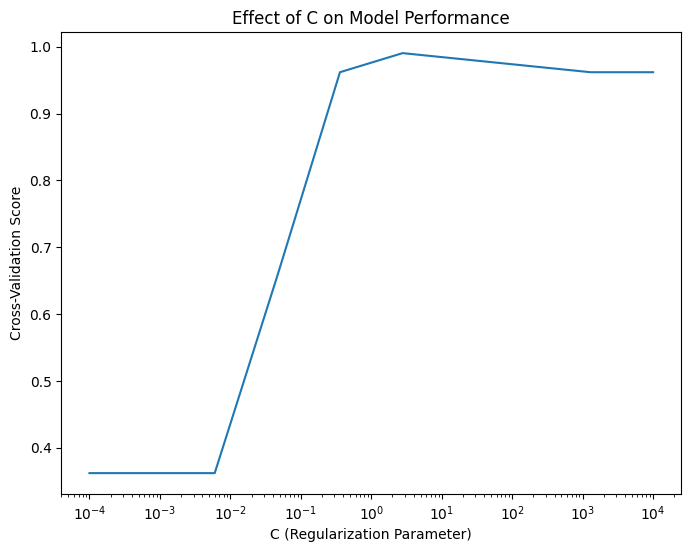

In [11]:
import numpy as np
import matplotlib.pyplot as plt

param_grid_c = {
  'C': np.logspace(-4, 4, 10),
  'kernel': ['rbf']
}

grid_search_c = GridSearchCV(SVC(), param_grid_c, cv=5)
grid_search_c.fit(X_train, y_train)

plt.figure(figsize=(8, 6))
plt.plot(
  grid_search_c.param_grid['C'],
  grid_search_c.cv_results_['mean_test_score']
)
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Cross-Validation Score')
plt.title('Effect of C on Model Performance')
plt.show()

Visualisasi tersebut membantu melihat dampak `C` terhadap trade-off antara margin dan misclassification error.

### Hands-on exercises

Alur latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Load dataset Iris menggunakan `load_iris()` dari `sklearn.datasets`.
3. Bersihkan dataset jika diperlukan.
4. Load `SVC` dari `sklearn.svm`.
5. Definisikan parameter grid untuk tuning.
6. Lakukan grid search dengan cross-validation menggunakan `GridSearchCV`.
7. Train model baru menggunakan parameter terbaik.
8. Evaluasi performa menggunakan accuracy score dan classification report.
9. Buat plot untuk melihat pengaruh hyperparameter terhadap performa model.

## SVMs in high-dimensional spaces

SVM efektif untuk data berdimensi tinggi, terutama ketika jumlah fitur besar dibandingkan jumlah sampel. Dataset seperti ini dapat disebut wide dataset.

Bagian ini menggunakan dataset sintetis dengan 1000 fitur.

### Persiapan dataset berdimensi tinggi

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

X, y = make_classification(
  n_samples=1000, n_features=1000,
  n_informative=50, n_redundant=0, random_state=2024
)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### Implementasi SVM pada data berdimensi tinggi

In [13]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report_df = pd.DataFrame(classification_report(
  y_test, y_pred, output_dict=True
)).transpose()

styled_report_df = (report_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df

Accuracy: 0.75


,precision,recall,f1-score,support
0,0.765,0.765,0.765,162
1,0.725,0.725,0.725,138
accuracy,0.747,0.747,0.747,1
macro avg,0.745,0.745,0.745,300
weighted avg,0.747,0.747,0.747,300


Pada contoh materi, penggunaan argumen default pada dataset berdimensi tinggi tidak menghasilkan performa terkuat.

### Cara kerja SVM pada data berdimensi tinggi

SVM dapat menangani data berdimensi tinggi dengan bantuan kernel functions.

- Linear kernel cocok untuk data yang dapat dipisahkan secara linear atau ketika jumlah fitur besar.
- Non-linear kernel seperti RBF atau polynomial cocok untuk data yang tidak dapat dipisahkan secara linear.

### Visualisasi data berdimensi tinggi menggunakan PCA

Data berdimensi tinggi sulit divisualisasikan langsung. PCA dapat digunakan untuk memproyeksikan data ke dua dimensi.

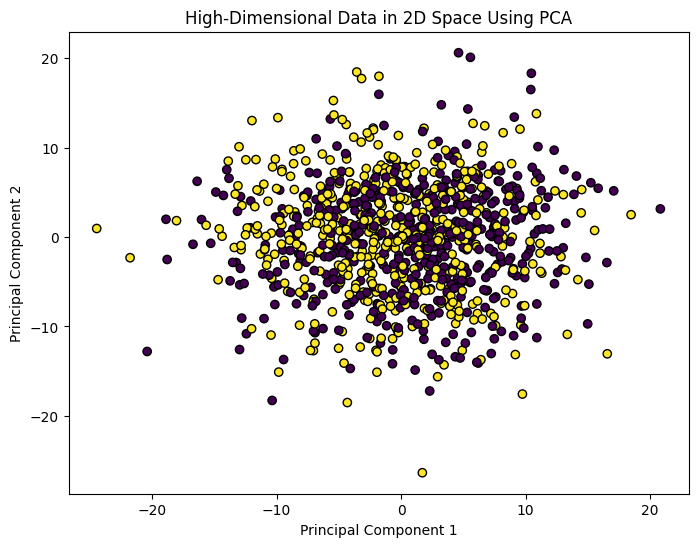

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(
  X_pca[:, 0], X_pca[:, 1], c=y,
  edgecolors='k', marker='o'
)
plt.title("High-Dimensional Data in 2D Space Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Setelah PCA, separasi kelas pada dua komponen utama dapat tetap sulit jika struktur data memang kompleks.

### Hands-on exercises

Alur latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Buat dataset sintetis berdimensi tinggi menggunakan `make_classification()` dari `sklearn.datasets`.
3. Bersihkan dataset jika diperlukan.
4. Load `SVC` dari `sklearn.svm`.
5. Implementasikan SVM dengan kernel berbeda seperti linear atau RBF.
6. Evaluasi performa menggunakan accuracy score dan classification report.
7. Gunakan PCA untuk menurunkan dimensi dan memvisualisasikan data.
8. Coba parameter kernel berbeda untuk melihat pengaruhnya terhadap performa pada data berdimensi tinggi.

## Evaluating SVM models

Evaluasi model SVM penting untuk mengetahui kemampuan model dalam melakukan generalisasi pada data baru. Metrik yang digunakan mencakup accuracy, precision, recall, dan ROC curve.

Bagian ini menggunakan Breast Cancer dataset.

### Persiapan data evaluasi SVM

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
  accuracy_score, classification_report, roc_curve, auc
)
import pandas as pd
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### Evaluasi SVM dengan classification report dan ROC curve

In [16]:
svm_model = SVC(kernel='linear', probability=True)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(
  y_test, y_pred, output_dict=True
)
report_df = pd.DataFrame(report).transpose()

styled_report_df = (report_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f"Accuracy: {accuracy:.2f}")
styled_report_df

Accuracy: 0.95


,precision,recall,f1-score,support
0,0.926,0.940,0.933,67
1,0.961,0.952,0.957,104
accuracy,0.947,0.947,0.947,1
macro avg,0.944,0.946,0.945,171
weighted avg,0.948,0.947,0.947,171


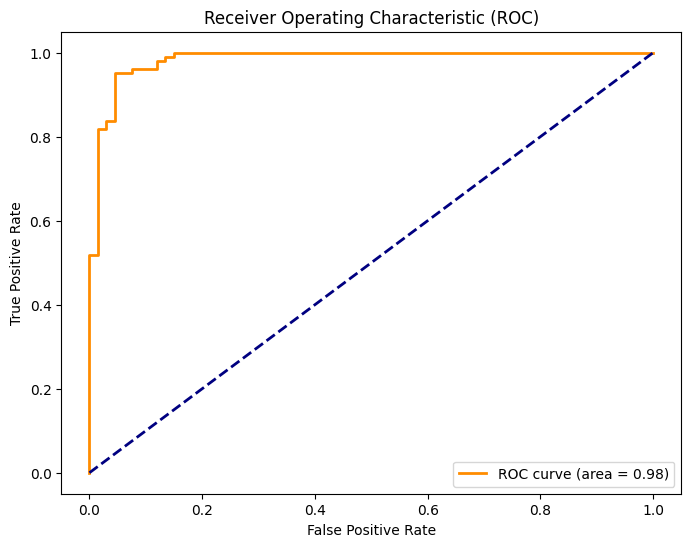

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
  fpr, tpr, color='darkorange', lw=2,
  label=f'ROC curve (area = {roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

ROC curve memvisualisasikan true positive rate terhadap false positive rate pada berbagai threshold. Garis diagonal menunjukkan model yang tidak lebih baik dari tebakan acak. AUC merangkum kemampuan model dalam membedakan kelas positif dan negatif.

### Cara kerja metrik evaluasi SVM

- Accuracy: proporsi prediksi yang benar.
- Precision: proporsi true positive dari semua prediksi positif.
- Recall: proporsi true positive dari semua data yang sebenarnya positif.
- F1-score: harmonic mean antara precision dan recall.
- ROC curve: memplot true positive rate terhadap false positive rate pada berbagai threshold.
- AUC: mengukur kemampuan model membedakan kelas positif dan negatif.

Pemilihan metrik bergantung pada tujuan klasifikasi. Jika false positive mahal, precision lebih penting. Jika menangkap sebanyak mungkin kasus positif lebih penting, recall lebih penting.

### Hands-on exercises

Alur latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Load Breast Cancer dataset menggunakan `load_breast_cancer()` dari `sklearn.datasets`.
3. Bersihkan dataset jika diperlukan.
4. Load `SVC` dari `sklearn.svm`.
5. Fit model menggunakan data training.
6. Gunakan `predict` pada data testing.
7. Hitung metrik seperti accuracy score, precision, recall, F1-score, dan ROC AUC.
8. Buat plot ROC curve untuk mengevaluasi performa model pada berbagai threshold.

## Practical exercises with SVMs

Bagian akhir materi berisi latihan praktis untuk membangun, melakukan tuning, dan mengevaluasi model SVM.

### Exercise 1: Building a simple SVM classifier

Langkah implementasi:

1. Load libraries.
2. Load dataset.
3. Split data.
4. Create and train an SVM classifier.
5. Make predictions.
6. Evaluate performance.

### Exercise 2: Tuning SVM parameters with grid search

Latihan ini menggunakan Breast Cancer dataset untuk tuning parameter SVM dengan grid search.

Langkah implementasi:

1. Load libraries.
2. Load dataset.
3. Split data.
4. Define a hyperparameter for grid search.
5. Perform grid search with cross-validation.
6. Train a new model with the best hyperparameters.
7. Make predictions with the best model.
8. Evaluate the best model.

### Exercise 3: Visualizing SVM decision boundaries

Latihan ini memvisualisasikan decision boundary dari model SVM pada dataset sintetis.

Langkah implementasi:

1. Load libraries for visualization and dataset creation.
2. Create a synthetic dataset for binary classification.
3. Split the data.
4. Create and train an SVM model.
5. Create a mesh grid for plotting decision boundaries.
6. Predict class probabilities across the grid.
7. Plot decision boundaries.